In [1]:
%pip install --upgrade pip
%pip install matplotlib --no-cache-dir

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


#  Bài toán Dự đoán Giá nhà (Linear Regression)

**Mục tiêu:** Xây dựng mô hình Hồi quy tuyến tính (Linear Regression) để dự đoán giá bán của một ngôi nhà dựa trên diện tích của nó.
**Dữ liệu:** Sử dụng bộ dữ liệu gồm 40 mẫu từ file `data_gia_nha.csv`.

Trong Machine Learning, bài toán này tìm kiếm một đường thẳng tối ưu đi qua các điểm dữ liệu, có phương trình dạng: 
$$\hat{y} = w_1x + w_0$$
Trong đó:
* **$x$**: Diện tích nhà (Biến độc lập / Feature)
* **$\hat{y}$**: Giá nhà dự đoán (Biến phụ thuộc / Target)
* **$w_1$**: Hệ số góc (Slope) - Mức độ tăng giá theo mỗi $m^2$
* **$w_0$**: Hệ số chặn (Intercept)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression as lr

df = pd.read_csv('data.csv')
print(df.head())

print(df.describe())

print(f"\n Tổng số dữ liệu: {len(df)}")

   Dien_tich  Gia_ban
0      30.00   448.52
1      32.41   509.25
2      34.83   535.10
3      37.24   551.43
4      39.66   623.42
        Dien_tich      Gia_ban
count   40.000000    40.000000
mean    70.153500  1119.986750
std     23.489849   401.134661
min     30.000000   448.520000
25%     50.650000   783.975000
50%     70.300000  1110.350000
75%     89.825000  1453.925000
max    110.000000  1810.000000

 Tổng số dữ liệu: 40


In [3]:
X = df[['Dien_tich']].values
y = df['Gia_ban'].values

print(X)
print(y)

[[ 30.  ]
 [ 32.41]
 [ 34.83]
 [ 37.24]
 [ 39.66]
 [ 41.5 ]
 [ 43.2 ]
 [ 45.1 ]
 [ 47.  ]
 [ 49.  ]
 [ 51.2 ]
 [ 53.  ]
 [ 55.4 ]
 [ 57.1 ]
 [ 59.2 ]
 [ 61.  ]
 [ 63.5 ]
 [ 65.2 ]
 [ 67.  ]
 [ 69.1 ]
 [ 71.5 ]
 [ 73.2 ]
 [ 75.  ]
 [ 77.4 ]
 [ 79.1 ]
 [ 81.3 ]
 [ 83.  ]
 [ 85.2 ]
 [ 87.  ]
 [ 89.4 ]
 [ 91.1 ]
 [ 93.  ]
 [ 95.2 ]
 [ 97.4 ]
 [ 99.  ]
 [101.2 ]
 [103.  ]
 [105.4 ]
 [107.1 ]
 [110.  ]]
[ 448.52  509.25  535.1   551.43  623.42  630.15  655.2   710.1   745.
  765.3   790.2   825.    845.5   880.    915.2   950.1   985.4  1020.1
 1055.3  1090.2  1130.5  1160.2  1195.   1230.1  1265.4  1300.2  1335.1
 1370.5  1405.   1445.2  1480.1  1515.4  1550.2  1590.3  1625.   1660.1
 1695.2  1735.1  1770.4  1810.  ]


###  Huấn luyện Mô hình và Thực hiện Dự đoán
Chúng ta sẽ sử dụng thư viện `scikit-learn` để máy tính tự động tìm ra đường thẳng tối ưu (giảm thiểu sai số MSE). Sau đó, yêu cầu máy dự đoán giá cho một ngôi nhà có diện tích **$50m^2$**.

In [4]:
model = lr()
model.fit(X,y)

x_ask = np.array([[50]]) # dien tich moi, diện tích cần dự đoán
y_ask = model.predict(x_ask) #Gia du doan

print("Ket qua")
print(f"Diện tích bạn nhập: {x_ask[0][0]} m2")
print(f"Máy tính dự đoán giá là: {y_ask[0]:.2f} triệu VNĐ")



Ket qua
Diện tích bạn nhập: 50 m2
Máy tính dự đoán giá là: 776.03 triệu VNĐ


### Trực quan hóa Kết quả
Vẽ đồ thị phân tán (Scatter plot) của 40 điểm dữ liệu thực tế, lồng ghép với đường thẳng hồi quy (Regression Line) và đánh dấu vị trí của điểm dự đoán $50m^2$ để kiểm chứng bằng mắt thường.

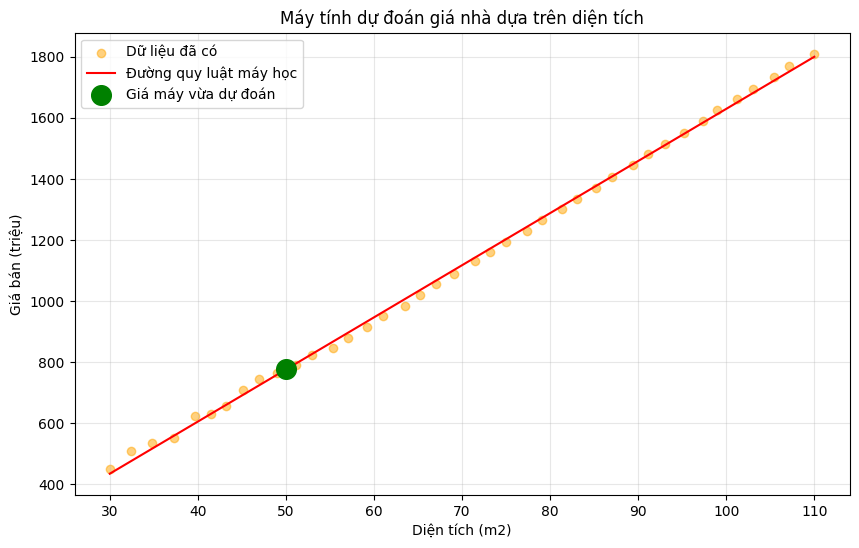

[776.02754776]


In [5]:
plt.figure(figsize=(10, 6))

# Vẽ toàn bộ dữ liệu cũ (chấm cam)
plt.scatter(X, y, color='orange', alpha=0.5, label='Dữ liệu đã có')

# Vẽ đường thẳng quy luật mà máy tính tìm được
plt.plot(X, model.predict(X), color='red', label='Đường quy luật máy học')

# TÍCH HỢP ĐIỂM CHẤM XANH TẠI Ô 50
plt.scatter(x_ask, y_ask, color='green', s=200, label='Giá máy vừa dự đoán', zorder=5)

# Thêm nhãn và trang trí
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá bán (triệu)')
plt.title('Máy tính dự đoán giá nhà dựa trên diện tích')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(y_ask)